In [480]:
# Add any additional libraries or submodules below

# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [481]:
df = pd.read_csv("unicef_malawi.csv")
df.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
0,1.0,2.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,YES,NO
1,1.0,3.0,1.0,1.0,5.0,YES,ECE,NaN,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,YES
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
3,1.0,8.0,2.0,2.0,13.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO
4,1.0,10.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,8.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO


To avoid any bias/data leakage, best practice is to split the data to triaing/test before any EDA / Feature Engineering.

However, in order to be able to split the data, all missing data needs to be dealt with. At times .``dropna()`` (remove missing data) can be applied for simplicity, provided we don't lose too much information.

In order to understand run df.info() to understand the structure of the data, missing data, data types etc

In [482]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13059 non-null  float64
 5   CB4         13059 non-null  object 
 6   CB5A        12203 non-null  object 
 7   CB5B        11575 non-null  object 
 8   CB7         12203 non-null  object 
 9   CB11        13059 non-null  object 
 10  CL3         4159 non-null   float64
 11  CL13        11092 non-null  object 
 12  FCD2A       11264 non-null  object 
 13  FCD2B       11264 non-null  object 
 14  FCD2C       11264 non-null  object 
 15  FCD2D       11264 non-null  object 
 16  FCD2E       11264 non-null  object 
 17  FCD2F       11264 non-null  object 
 18  FCD2G       11264 non-null  object 
 19  FCD2H       11264 non-nul

### 1. Tidy up NaNs

1.1 Observation: 

some columns have significant amount of data missing (CL3 (Child Labour)/FCD5(physical punishment)/HW5 (Handwashing)). If these were insignificant, could be just dropped. 

However, knowing how great of an impact kind/gentle/loving physical touch (hugging etc (oxitocin)) and playfull time can have on a child's early development of the brain (see chimpanzee study on baby chimpanzees deprived of food vs deprived of physical touch / children born during war times etc), intuitively child labour and physical punishment columns likely were going to be the ones we want to keep.

Handwashing metric, although not intuitive, can potentially translate to mental health as well (thinking dirt -> inflammation -> long-term alert state of the body -> constant fight-or-flight mode -> depression). Similarly, the gut's microbiome could be affected by this, which has been shown to have direct connection with mental health as well.

`Conclusion:` we likely want to keep these columns

1.2 Let's explore the pattern of missing data (how many in total vs. how many rows are affected)

In [483]:
print(f"Total NaNs: {df.isnull().sum().sum()}")
print(f"Rows with any NaN: {df.isnull().any(axis=1).sum()}")
print(f"Total NO \"RESPONSE\": {(df == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df[df == "NO RESPONSE"].any(axis=1).sum()}")


Total NaNs: 71374
Rows with any NaN: 12458
Total NO "RESPONSE": 1293
Rows with any "NO RESPONSE": 1121


IF there is a row that has all values NA -> remove this row

In [484]:
df.dropna(how='all') 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13059 non-null  float64
 5   CB4         13059 non-null  object 
 6   CB5A        12203 non-null  object 
 7   CB5B        11575 non-null  object 
 8   CB7         12203 non-null  object 
 9   CB11        13059 non-null  object 
 10  CL3         4159 non-null   float64
 11  CL13        11092 non-null  object 
 12  FCD2A       11264 non-null  object 
 13  FCD2B       11264 non-null  object 
 14  FCD2C       11264 non-null  object 
 15  FCD2D       11264 non-null  object 
 16  FCD2E       11264 non-null  object 
 17  FCD2F       11264 non-null  object 
 18  FCD2G       11264 non-null  object 
 19  FCD2H       11264 non-nul

In [485]:
print(f"Total NaNs: {df.isnull().sum().sum()}")
print(f"Rows with any NaN: {df.isnull().any(axis=1).sum()}")
print(f"Total NO \"RESPONSE\": {(df == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df[df == "NO RESPONSE"].any(axis=1).sum()}")


Total NaNs: 71374
Rows with any NaN: 12458
Total NO "RESPONSE": 1293
Rows with any "NO RESPONSE": 1121


12,458 rows out of 13,162 have a NaN value. No rows are `entirely` empty. Using dropna() would remove *95%* of data. Likely better ways of dealing with this!

However, only 103 of the target (FCF26) entries are missing (0.8%). These are dropped now as the number is insignificant and we have to know the outcome for training.

`Conclusion:` Remove FCF26 missing rows. Otherwise, to avoid doing too much work (introducing bias) before splitting the data, we're globally filling in the missing values with one of the already used term in the dataset — 'NO RESPONSE'.

In [486]:
df[df.isin(['NO RESPONSE']).any(axis=1)]

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
16,2.0,4.0,2.0,2.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 4,YES,NO,...,NO,YES,PIPED WATER: PIPED TO YARD / PLOT,NaN,NaN,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,NaN
31,3.0,17.0,2.0,2.0,8.0,YES,PRIMARY,CLASS/YEAR/GRADE 3,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,20.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,NO,NO
39,4.0,5.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,DUG WELL: PROTECTED WELL,ELSEWHERE,20.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NaN
67,6.0,14.0,2.0,2.0,7.0,YES,PRIMARY,CLASS/YEAR/GRADE 1,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,25.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13026,1101.0,4.0,1.0,1.0,14.0,YES,PRIMARY,CLASS/YEAR/GRADE 5,YES,NO RESPONSE,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,90.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NO
13100,1107.0,4.0,2.0,2.0,5.0,YES,ECE,NaN,YES,NO,...,YES,YES,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,10.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NaN
13124,1109.0,1.0,1.0,1.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 4,YES,NO,...,NO,NO,TUBE WELL / BOREHOLE,ELSEWHERE,150.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NaN
13127,1109.0,7.0,2.0,2.0,5.0,YES,ECE,NaN,YES,NO,...,NO,NO,DUG WELL: UNPROTECTED WELL,NO RESPONSE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,YES


In [487]:
df = df[df['FCF26'].notna()]
df = df.fillna('NO RESPONSE')

Confirming no data is missing now and the df size reduced to 13059:

In [488]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13059 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13059 non-null  float64
 1   HH2         13059 non-null  float64
 2   LN          13059 non-null  float64
 3   FS4         13059 non-null  float64
 4   CB3         13059 non-null  float64
 5   CB4         13059 non-null  object 
 6   CB5A        13059 non-null  object 
 7   CB5B        13059 non-null  object 
 8   CB7         13059 non-null  object 
 9   CB11        13059 non-null  object 
 10  CL3         13059 non-null  object 
 11  CL13        13059 non-null  object 
 12  FCD2A       13059 non-null  object 
 13  FCD2B       13059 non-null  object 
 14  FCD2C       13059 non-null  object 
 15  FCD2D       13059 non-null  object 
 16  FCD2E       13059 non-null  object 
 17  FCD2F       13059 non-null  object 
 18  FCD2G       13059 non-null  object 
 19  FCD2H       13059 non-null  ob

### 2. Now that we've removed missing values, let's split the data into training and test sets. Column FCF26 is our target (y)

we're using the common 80/20 split for trainig/test, respectively

In [489]:
X = df.drop(columns=['FCF26']) 
y = df['FCF26']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=8, ## fixing the state for reproducibility
    stratify=y      ## to guarantee balanced split of data
)

#saving as separate dfs
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

### 3. Now, let's clean up properly the missing data

All decisions will be made solely on investigating the structures in the training dataset and will be just applied to the test dataset.

### 4. Checking for patterns/correlation in data

<Axes: >

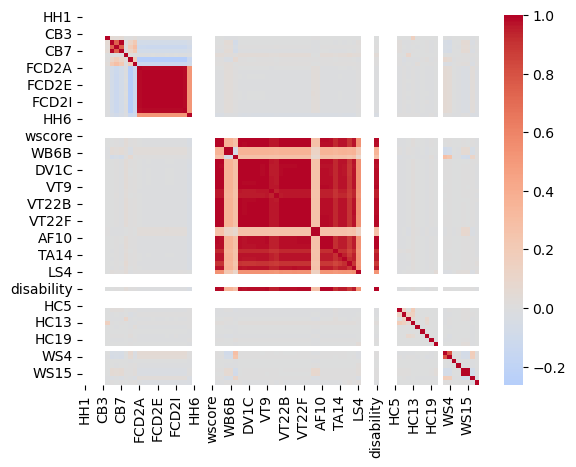

In [490]:
no_response_matrix = (df_train == 'NO RESPONSE').astype(int)
no_response_corr = no_response_matrix.corr()
sns.heatmap(no_response_corr, cmap='coolwarm', center=0, annot=False)

`Conclusion:` Clear patterns (red squares) in missing responses. This will be investigated in more detail section by section.

#### 4.1 Child Labour

In [491]:
cols = ['CL2','CL3', 'CL12', 'CL13', 'FCF26']
df_train[df_train['CL3'].isin(['NO RESPONSE'])][cols]

,CL2,CL3,CL12,CL13,FCF26
9683,False,NO RESPONSE,True,2.0,NEVER
3729,False,NO RESPONSE,True,1.0,MONTHLY
12137,False,NO RESPONSE,False,NO RESPONSE,NEVER
7959,False,NO RESPONSE,True,3.0,A FEW TIMES A YEAR
11534,False,NO RESPONSE,False,NO RESPONSE,WEEKLY
...,...,...,...,...,...
5169,False,NO RESPONSE,False,NO RESPONSE,A FEW TIMES A YEAR
10802,False,NO RESPONSE,True,0.0,WEEKLY
1426,False,NO RESPONSE,True,1.0,WEEKLY
2767,False,NO RESPONSE,True,1.0,NEVER


In [492]:
## check how False / True translates to CL2
df_train[df_train['CL3'] == 'NO RESPONSE']['CL2'].value_counts(normalize=True)

CL2
False    1.0
Name: proportion, dtype: float64

_`Conclusion`: wherever CL2 is False (Child Labour = False), there's a missing CL3 value. This means, all CL3 missing values can be set to 0.0 worked hours_

In [493]:
df_train['CL3'] = df_train['CL3'].replace('NO RESPONSE', 0.0)
df_test['CL3'] = df_test['CL3'].replace('NO RESPONSE', 0.0)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_4043/2669409082.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['CL3'] = df_train['CL3'].replace('NO RESPONSE', 0.0)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_4043/2669409082.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['CL3'] = df_test['CL3'].replace('NO RESPONSE', 0.0)


In [494]:
df_train[df_train['CL13'] == 'NO RESPONSE']['CL12'].value_counts(normalize=True)

CL12
False    0.997475
True     0.002525
Name: proportion, dtype: float64

_99.7% of data for CL13 and CL12 follow the same rule_

`Conclusion:` _similarly, we make CL13 missing data 0.0_

In [495]:
df_train['CL13'] = df_train['CL13'].replace('NO RESPONSE', 0.0)
df_test['CL13'] = df_test['CL13'].replace('NO RESPONSE', 0.0)

In [ ]:
# just checking the status of the missing values
print(f"Total NO \"RESPONSE\": {(df_train == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df_train[df_train == "NO RESPONSE"].any(axis=1).sum()}")

Total NO "RESPONSE": 46412
Rows with any "NO RESPONSE": 8794


Checking key missing-value columns for further investigation/work

In [497]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD5         3935
HW5          2771
MA3          2382
MA2          2358
WB14         2305
             ... 
MSTATUS         0
HH7             0
HL4             0
ethnicity       0
HH1             0
Length: 87, dtype: int64

FCD5. _Do you believe that in order to bring up, raise, or educate a child properly, the child needs to be physically punished?_\
checing correlation with other FCD columns

FCD2A-K are different types of physical punishment methods

In [498]:
fcd_cols = ['FCD5','FCD2A','FCD2B', 'FCD2C',
'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']
df_train[df_train['FCD5'] == 'NO RESPONSE'][fcd_cols + ['FCF26']]

,FCD5,FCD2A,FCD2B,FCD2C,FCD2D,FCD2E,FCD2F,FCD2G,FCD2H,FCD2I,FCD2J,FCD2K,FCF26
9683,NO RESPONSE,YES,YES,NO,NO,NO,NO,NO,NO,NO,NO,NO,NEVER
4896,NO RESPONSE,YES,YES,YES,YES,YES,YES,NO,YES,YES,YES,NO,NEVER
12137,NO RESPONSE,YES,YES,YES,NO,YES,NO,NO,NO,NO,NO,NO,NEVER
7959,NO RESPONSE,NO,YES,NO,YES,NO,NO,NO,YES,NO,NO,NO,A FEW TIMES A YEAR
11534,NO RESPONSE,YES,YES,YES,NO,NO,NO,NO,YES,NO,NO,NO,WEEKLY
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3637,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,WEEKLY
10770,NO RESPONSE,YES,YES,NO,YES,NO,NO,NO,NO,NO,NO,NO,WEEKLY
7541,NO RESPONSE,YES,YES,YES,YES,YES,YES,NO,YES,NO,NO,NO,A FEW TIMES A YEAR
11533,NO RESPONSE,YES,YES,NO,YES,NO,YES,YES,YES,NO,NO,NO,MONTHLY


In [499]:
df_train[df_train['FCD2K'] == 'NO RESPONSE'][fcd_cols].value_counts(normalize=True)

FCD5         FCD2A        FCD2B        FCD2C        FCD2D        FCD2E        FCD2F        FCD2G        FCD2H        FCD2I        FCD2J        FCD2K      
NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE  NO RESPONSE    0.985666
NO           NO           NO           NO           NO           NO           NO           NO           NO           NO           NO           NO RESPONSE    0.000683
                          YES          NO           NO           NO           NO           YES          NO           YES          YES          NO RESPONSE    0.000683
YES          NO           YES          NO           YES          YES          NO           NO           YES          YES          NO           NO RESPONSE    0.000683
NO RESPONSE  YES          YES          YES          YES          NO           YES          NO           YES          NO           NO           NO RESPONSE    0.000683
          

<Axes: >

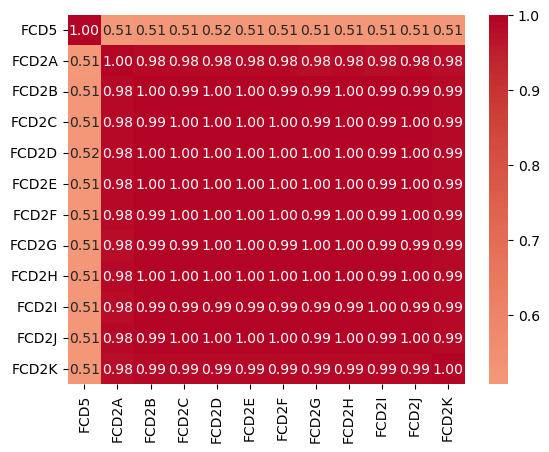

In [500]:
fcd_no_resp = (df_train[fcd_cols] == 'NO RESPONSE').astype(int)
sns.heatmap(fcd_no_resp.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f')

_Conclusion: If there is missing data for one Physical punishment type (FCD2) column, it is missing in almost all the other FCD2X ones -> it looks like an intentional skip, but we can't quite tell if it's missed because a person doesn't want to disclose what kind of punishment they use OR they don't agree with punishment. First step: if FCD2 columns are ALL "NO", make FCD5 "NO RESPONSE" a "NO" too. If there's any "YES" make it a "YES"._

In [501]:
fcd2_cols = ['FCD2A','FCD2B', 'FCD2C',
'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']

for df in [df_train, df_test]:
    mask = df['FCD5'].isin(['NO RESPONSE', 'DK / NO OPINION'])
    
    any_yes = df.loc[mask, fcd2_cols].isin(['YES']).any(axis=1)
    df.loc[mask & any_yes, 'FCD5'] = 'YES'
    
    all_no = (df.loc[mask, fcd2_cols] == 'NO').all(axis=1)
    df.loc[mask & all_no, 'FCD5'] = 'NO'

In [502]:
df_train['FCD5'].value_counts()

FCD5
NO             5458
YES            3542
NO RESPONSE    1447
Name: count, dtype: int64

In [503]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5          2771
MA3          2382
MA2          2358
WB14         2305
FCD2A        1480
             ... 
MSTATUS         0
HH7             0
HL4             0
ethnicity       0
HH1             0
Length: 87, dtype: int64

HW5. _Do you have any soap or detergent or ash/mud/sand in your house for washing hands?_

MA2. How old is your (husband/partner)?
Probe: How old was your (husband/partner) on his last birthday?

MA3. Besides yourself, does your (husband/partner) have any other wives or partners or does he live with other women as if married?

In [504]:
top_NaNs_cols = ['HW5','MA3', 'MA2']
df_train[df_train['MA2'] == 'NO RESPONSE'][top_NaNs_cols + ['FCF26']]

,HW5,MA3,MA2,FCF26
7959,YES,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR
4388,NO,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR
13057,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
9521,YES,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR
8185,NO,NO RESPONSE,NO RESPONSE,NEVER
...,...,...,...,...
12235,NO,NO RESPONSE,NO RESPONSE,NEVER
2573,NO,NO RESPONSE,NO RESPONSE,NEVER
3637,YES,NO RESPONSE,NO RESPONSE,WEEKLY
7279,NO,NO RESPONSE,NO RESPONSE,A FEW TIMES A YEAR


In [505]:
df_train[df_train['MA3'] == 'NO RESPONSE']['MSTATUS'].value_counts(normalize=True)

MSTATUS
Formerly married/in union     0.842569
Never married/in union        0.088581
Currently married/in union    0.068850
Name: proportion, dtype: float64

In [506]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

married_mask_train = df_train['MSTATUS'] == 'Currently married/in union'
married_mask_test = df_test['MSTATUS'] == 'Currently married/in union'

df_train.loc[married_mask_train, ['MA2', 'MA3']] = imputer.fit_transform(
    df_train.loc[married_mask_train, ['MA2', 'MA3']]
)
df_test.loc[married_mask_test, ['MA2', 'MA3']] = imputer.transform(
    df_test.loc[married_mask_test, ['MA2', 'MA3']]
)

In [507]:
df_train['MA2'].value_counts(normalize=True)

MA2
NO RESPONSE    0.212310
40.0           0.053795
35.0           0.038959
45.0           0.035034
37.0           0.032545
                 ...   
85.0           0.000096
12.0           0.000096
13.0           0.000096
83.0           0.000096
16.0           0.000096
Name: proportion, Length: 71, dtype: float64

In [508]:
df_train.loc[df_train['MA2'] == 'NO RESPONSE', 'MA2'] = 0.0
df_train.loc[df_train['MA3'] == 'NO RESPONSE', 'MA3'] = 'NOT MARRIED'
df_test.loc[df_test['MA2'] == 'NO RESPONSE', 'MA2'] = 0.0
df_test.loc[df_test['MA3'] == 'NO RESPONSE', 'MA3'] = 'NOT MARRIED'

MA2 and MA3 perfect correlation — likely no husband -> leaving as "NO RESPONSE"

WB5. _Have you ever attended school or any early childhood education programme?_

WB6. _What is the highest level and grade or year of school you have attended?_

In [509]:
top_NaNs_cols = ['HW5','WB14', 'WB5', 'WB6B', 'WB6A']
df_train[df_train['WB14'] == 'NO RESPONSE'][top_NaNs_cols + ['FCF26']]

,HW5,WB14,WB5,WB6B,WB6A,FCF26
9683,NO,NO RESPONSE,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,NEVER
4896,NO,NO RESPONSE,YES,CLASS/YEAR/GRADE 2,LOWER SECONDARY,NEVER
12137,NO,NO RESPONSE,YES,CLASS/YEAR/GRADE 1,LOWER SECONDARY,NEVER
114,YES,NO RESPONSE,YES,CLASS/YEAR/GRADE 2,LOWER SECONDARY,A FEW TIMES A YEAR
4388,NO,NO RESPONSE,YES,CLASS/YEAR/GRADE 2,LOWER SECONDARY,A FEW TIMES A YEAR
...,...,...,...,...,...,...
7101,NO,NO RESPONSE,NO RESPONSE,NO RESPONSE,NO RESPONSE,NEVER
2573,NO,NO RESPONSE,YES,CLASS/YEAR/GRADE 4,UPPER SECONDARY,NEVER
13023,NO RESPONSE,NO RESPONSE,YES,CLASS/YEAR/GRADE 2,LOWER SECONDARY,NEVER
3995,YES,NO RESPONSE,YES,CLASS/YEAR/GRADE 3,UPPER SECONDARY,A FEW TIMES A YEAR


In [510]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='DK')

df_train[['MA2']] = imputer.fit_transform(df_train[['MA2']])
df_test[['MA2']] = imputer.transform(df_test[['MA2']])

In [511]:
print(df_train['WB5'].value_counts(normalize=True))
print(df_train['WB6A'].value_counts(normalize=True))
print(df_train['WB6B'].value_counts(normalize=True))
print(df_train['WB14'].value_counts(normalize=True))

WB5
YES            0.859577
NO             0.118886
NO RESPONSE    0.021537
Name: proportion, dtype: float64
WB6A
PRIMARY                0.659615
NO RESPONSE            0.140423
LOWER SECONDARY        0.096008
UPPER SECONDARY        0.084235
HIGHER                 0.017804
VOCATIONAL TRAINING    0.001532
ECE                    0.000383
Name: proportion, dtype: float64
WB6B
CLASS/GRADE 8         0.143199
CLASS/YEAR/GRADE 4    0.141093
NO RESPONSE           0.140806
CLASS/YEAR/GRADE 2    0.125682
CLASS/GRADE 7         0.106442
CLASS/YEAR/GRADE 3    0.099454
CLASS/YEAR/GRADE 5    0.096583
CLASS/GRADE 6         0.084618
CLASS/YEAR/GRADE 1    0.062027
DK                    0.000096
Name: proportion, dtype: float64
WB14
ABLE TO READ WHOLE SENTENCE                   0.355030
CANNOT READ AT ALL                            0.340863
NO RESPONSE                                   0.220638
ABLE TO READ ONLY PARTS OF SENTENCE           0.081172
NO SENTENCE IN REQUIRED LANGUAGE / BRAILLE    0.002297
N

In [512]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[['WB6A', 'WB6B', 'WB14']] = imputer.fit_transform(df_train[['WB6A','WB6B', 'WB14']])
df_test[['WB6A','WB6B', 'WB14']] = imputer.transform(df_test[['WB6A','WB6B', 'WB14']])
df_train.loc[df_train['WB5'] == 'NO RESPONSE', 'WB5'] = 'NO'
df_test.loc[df_test['WB5'] == 'NO RESPONSE', 'WB5'] = 'NO'

If WB5 is "NO" or NaN, WB6A and WB6B have missing values. Most likely the woman just didn't attend school. WB14 for most of the WB5/6A/6B entries is "CANNOT READ AT ALL" with a few exceptions -> changing WB5 to "NO" and WB6A/B to "NO EDUCATION";

In [513]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5      2771
FCD2A    1480
FCD2K    1465
FCD2I    1457
FCD2G    1452
         ... 
CDEAD       0
HH6         0
CL2         0
CL12        0
HH1         0
Length: 87, dtype: int64

WS1. _What is the main source of drinking water used by members of your household?_

WS3. _Where is that water source located?_

WS4. _How long does it take for members of your household to go there, get water, and come back?_

WS7. _In the last month, has there been any time when your household did not have sufficient quantities of drinking water?_

WS11. _What kind of toilet facility do members of your household usually use?_

WS14. _Where is this toilet facility located?_

WS15. _Do you share this facility with others who are not members of your household?_

In [514]:
household_cols = ['HW5', 'WS1', 'WS3', 'WS4', 'WS7', 'WS11', 'WS14', 'WS15']
df_train[df_train['WS4'] == 'NO RESPONSE'][household_cols + ['FCF26']]

,HW5,WS1,WS3,WS4,WS7,WS11,WS14,WS15,FCF26
5543,NO,DUG WELL: UNPROTECTED WELL,IN OWN YARD / PLOT,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,WEEKLY
763,NO,TUBE WELL / BOREHOLE,IN OWN YARD / PLOT,NO RESPONSE,"YES, AT LEAST ONCE",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NEVER
11073,NO RESPONSE,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"YES, AT LEAST ONCE",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,NEVER
11072,NO,PIPED WATER: PIPED INTO DWELLING,NO RESPONSE,NO RESPONSE,"YES, AT LEAST ONCE",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,NEVER
8793,NO RESPONSE,PIPED WATER: PIPED INTO DWELLING,NO RESPONSE,NO RESPONSE,"YES, AT LEAST ONCE",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,A FEW TIMES A YEAR
...,...,...,...,...,...,...,...,...,...
2573,NO,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN DWELLING,NO,NEVER
6881,NO,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NEVER
13023,NO RESPONSE,PIPED WATER: PIPED INTO DWELLING,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK,IN OWN DWELLING,NO,NEVER
1426,NO,PIPED WATER: PIPED TO YARD / PLOT,NO RESPONSE,NO RESPONSE,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,WEEKLY


In [515]:
df_train.WS4.unique()

array(['10.0', '40.0', '5.0', '20.0', '30.0', 'DK', '60.0', '1.0', '50.0',
       '90.0', '70.0', '6.0', '12.0', 'NO RESPONSE', '45.0', '8.0',
       '65.0', '15.0', '100.0', '3.0', '160.0', '4.0', '120.0', '7.0',
       '25.0', '35.0', '26.0', 'MEMBERS DO NOT COLLECT', '2.0', '300.0',
       '80.0', '34.0', '18.0', '55.0', '23.0', '180.0', '17.0', '240.0',
       '54.0', '36.0', '13.0', '19.0', '21.0', '14.0', '360.0', '22.0',
       '16.0', '41.0', '24.0', '214.0', '155.0', '9.0', '28.0', '52.0',
       '11.0', '42.0', '540.0', '75.0', '130.0', '304.0', '98.0', '110.0',
       '610.0', '135.0', '112.0', '200.0', '46.0', '31.0', '153.0',
       '390.0', '95.0', '220.0', '33.0', '66.0', '900.0', '38.0', '49.0',
       '32.0', '27.0', '48.0'], dtype=object)

In [516]:
df_train[df_train['WS4'] == 'NO RESPONSE']['WS3'].value_counts(normalize=True)

WS3
NO RESPONSE           0.672143
IN OWN YARD / PLOT    0.310000
IN OWN DWELLING       0.017857
Name: proportion, dtype: float64

In [517]:
df_train['WS4'].value_counts(normalize=True)

WS4
10.0           0.159184
NO RESPONSE    0.134010
30.0           0.131617
20.0           0.108261
5.0            0.091701
                 ...   
42.0           0.000096
52.0           0.000096
214.0          0.000096
41.0           0.000096
48.0           0.000096
Name: proportion, Length: 80, dtype: float64

In [518]:
df_train[df_train['WS3'] == 'NO RESPONSE']['WS1'].value_counts(normalize=True)

WS1
PIPED WATER: PIPED TO YARD / PLOT                                            0.774590
PIPED WATER: PIPED INTO DWELLING                                             0.187500
TUBE WELL / BOREHOLE                                                         0.024590
DUG WELL: UNPROTECTED WELL                                                   0.003074
PACKAGED WATER: BOTTLED WATER                                                0.002049
DUG WELL: PROTECTED WELL                                                     0.002049
CART WITH SMALL TANK                                                         0.002049
PIPED WATER: PIPED TO NEIGHBOUR                                              0.001025
PIPED WATER: PUBLIC TAP / STANDPIPE                                          0.001025
TANKER-TRUCK                                                                 0.001025
SURFACE WATER (RIVER, DAM, LAKE, POND, STREAM, CANAL, IRRIGATION CHANNEL)    0.001025
Name: proportion, dtype: float64

most of missing data in WS3 has answers in WS1 -> Piped to yard/dwelling. 

Changing all NAs to "IN OWN YARD / PLOT". 

WS4 NaN for when WS3 "IN OWN YARD / PLOT", so changing to "MEMBERS DO NOT COLLECT"

In [519]:
df_train.loc[df_train['WS3'] == 'NO RESPONSE', 'WS3'] = 'IN OWN YARD / PLOT'
df_test.loc[df_test['WS3'] == 'NO RESPONSE', 'WS3'] = 'IN OWN YARD / PLOT'

In [520]:
df_train[df_train['WS4'] == 'NO RESPONSE']['WS3'].value_counts(normalize=True)

WS3
IN OWN YARD / PLOT    0.982143
IN OWN DWELLING       0.017857
Name: proportion, dtype: float64

In [521]:
df_train.loc[df_train['WS4'] == 'NO RESPONSE', 'WS4'] = 'MEMBERS DO NOT COLLECT'
df_test.loc[df_test['WS4'] == 'NO RESPONSE', 'WS4'] = 'MEMBERS DO NOT COLLECT'

In [522]:
df_train[df_train['WS14'] == 'NO RESPONSE']['WS11'].value_counts(normalize=True)

WS11
NO FACILITY / BUSH / FIELD          0.997459
HANGING TOILET / HANGING LATRINE    0.002541
Name: proportion, dtype: float64

99.7% have no toilet where "no response". changing no response to "NO TOILET"

In [523]:
df_train.loc[df_train['WS14'] == 'NO RESPONSE', 'WS14'] = 'NO TOILET'
df_test.loc[df_test['WS14'] == 'NO RESPONSE', 'WS14'] = 'NO TOILET'

In [524]:
df_train.WS4.unique()
df_train.WS4.value_counts()

WS4
10.0                      1663
MEMBERS DO NOT COLLECT    1424
30.0                      1375
20.0                      1131
5.0                        958
                          ... 
42.0                         1
52.0                         1
214.0                        1
41.0                         1
48.0                         1
Name: count, Length: 79, dtype: int64

In [525]:
df_train.loc[df_train['WS4'] == 'MEMBERS DO NOT COLLECT', 'WS4'] = 0.0
df_test.loc[df_test['WS4'] == 'MEMBERS DO NOT COLLECT', 'WS4'] = 0.0

In [526]:
df_train[df_train['WS4'] == 'DK']['WS3'].value_counts(normalize=True)

WS3
ELSEWHERE    1.0
Name: proportion, dtype: float64

Set to the most frequent value

In [527]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='DK')

df_train[['WS4']] = imputer.fit_transform(df_train[['WS4']])
df_test[['WS4']] = imputer.transform(df_test[['WS4']])

In [528]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

HW5        2771
FCD2A      1480
FCD2K      1465
FCD2I      1457
FCD2G      1452
           ... 
MSTATUS       0
CSURV         0
CDEAD         0
CL2           0
HH1           0
Length: 87, dtype: int64

In [529]:
df_train[df_train['WS15'] == 'NO RESPONSE']['WS14'].value_counts(normalize=True)


WS14
NO TOILET             0.988665
IN OWN YARD / PLOT    0.010076
ELSEWHERE             0.001259
Name: proportion, dtype: float64

Setting all "NO RESPONSE" to "YES" -> if they don't have a toilet, they share it with others, whether it's a bush or whatever else.

In [530]:
df_train.loc[df_train.WS15 == 'NO RESPONSE', 'WS15'] = 'YES'
df_test.loc[df_test.WS15 == 'NO RESPONSE', 'WS15'] = 'YES'

In [531]:
print(f"Total NO \"RESPONSE\": {(df_train == "NO RESPONSE").sum().sum()}")
print(f"Rows with any \"NO RESPONSE\": {df_train[df_train == "NO RESPONSE"].any(axis=1).sum()}")

Total NO "RESPONSE": 29759
Rows with any "NO RESPONSE": 5277


In [532]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS14'].value_counts(normalize=True)

WS14
IN OWN YARD / PLOT    0.782750
IN OWN DWELLING       0.095272
ELSEWHERE             0.082281
NO TOILET             0.039697
Name: proportion, dtype: float64

In [533]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS11'].value_counts(normalize=True)

WS11
PIT LATRINE: PIT LATRINE WITH SLAB                  0.743053
PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT    0.096716
PIT LATRINE: VENTILATED IMPROVED PIT LATRINE        0.053049
FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK            0.052689
NO FACILITY / BUSH / FIELD                          0.039697
OTHER                                               0.006135
FLUSH / POUR FLUSH: FLUSH TO PIPED SEWER SYSTEM     0.003970
HANGING TOILET / HANGING LATRINE                    0.001804
FLUSH / POUR FLUSH: FLUSH TO PIT LATRINE            0.001804
FLUSH / POUR FLUSH: FLUSH TO DK WHERE               0.000361
FLUSH / POUR FLUSH: FLUSH TO OPEN DRAIN             0.000361
COMPOSTING TOILET                                   0.000361
Name: proportion, dtype: float64

In [534]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS3'].value_counts(normalize=True)

WS3
ELSEWHERE             0.765428
IN OWN YARD / PLOT    0.231324
IN OWN DWELLING       0.003248
Name: proportion, dtype: float64

In [535]:
df_train[df_train['HW5'] == 'NO RESPONSE']['WS4'].value_counts(normalize=True)

WS4
0.0      0.233129
10.0     0.153013
30.0     0.116204
20.0     0.099242
5.0      0.086250
15.0     0.081559
60.0     0.063515
45.0     0.016961
25.0     0.016240
40.0     0.014435
2.0      0.012992
3.0      0.011187
120.0    0.011187
6.0      0.009744
8.0      0.009744
50.0     0.009022
4.0      0.007218
12.0     0.007218
7.0      0.006135
35.0     0.005774
1.0      0.004691
90.0     0.003248
13.0     0.001804
80.0     0.001804
14.0     0.001444
100.0    0.001444
55.0     0.001083
70.0     0.001083
9.0      0.000722
19.0     0.000722
180.0    0.000722
200.0    0.000722
21.0     0.000722
65.0     0.000722
300.0    0.000722
18.0     0.000722
240.0    0.000722
160.0    0.000722
49.0     0.000361
98.0     0.000361
135.0    0.000361
16.0     0.000361
32.0     0.000361
900.0    0.000361
214.0    0.000361
24.0     0.000361
11.0     0.000361
153.0    0.000361
22.0     0.000361
610.0    0.000361
36.0     0.000361
540.0    0.000361
17.0     0.000361
Name: proportion, dtype: float64

Most of the HW5 missing answers have latrines in their own yards, but water sources elsewhere, so most likely don't wash their hands. Changing 'NO RESPONSE' to 'NO'

In [536]:
df_train.loc[df_train.HW5 == 'NO RESPONSE', 'HW5'] = 'NO'
df_test.loc[df_test.HW5 == 'NO RESPONSE', 'HW5'] = 'NO'

In [537]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A      1480
FCD2K      1465
FCD2I      1457
FCD2G      1452
FCD2B      1452
           ... 
MSTATUS       0
CSURV         0
CDEAD         0
CB3           0
HH1           0
Length: 87, dtype: int64

CB3. How old is (name)?  

CB4. Has (name) ever attended school or any early childhood education programme?

CB5. What is the highest level and grade or year of school (name) has ever attended?

CB7. At any time during the current school year did (name) attend school or any early childhood education programme?

CB11. Is (name) covered by any health insurance?

In [538]:
df_train.CB5A.unique()

array(['PRIMARY', 'ECE', 'NO RESPONSE', 'LOWER SECONDARY',
       'UPPER SECONDARY', 'HIGHER'], dtype=object)

In [539]:
df_train[df_train['CB5A'] == 'NO RESPONSE']['CB3'].value_counts(normalize=True)

CB3
5.0     0.604196
6.0     0.180420
7.0     0.068531
8.0     0.032168
10.0    0.022378
9.0     0.019580
15.0    0.016783
14.0    0.011189
12.0    0.011189
17.0    0.009790
11.0    0.008392
13.0    0.008392
16.0    0.006993
Name: proportion, dtype: float64

likely just not in school age yet!

In [540]:
df_train[df_train['CB5B'] == 'NO RESPONSE']['CB4'].value_counts(normalize=True)

CB4
NO             0.589404
YES            0.408940
NO RESPONSE    0.001656
Name: proportion, dtype: float64

In [541]:
df_train[df_train['CB7'] == 'NO RESPONSE']['CB3'].value_counts(normalize=True)

CB3
5.0     0.605042
6.0     0.180672
7.0     0.068627
8.0     0.032213
10.0    0.022409
9.0     0.019608
15.0    0.016807
14.0    0.011204
12.0    0.011204
17.0    0.009804
11.0    0.008403
13.0    0.007003
16.0    0.007003
Name: proportion, dtype: float64

changing NO RESPONSE to NOT SCHOOL AGE in both CB5A and CB5B

In [542]:
df_train.loc[df_train.CB5B == 'NO RESPONSE', 'CB5B'] = 'NOT SCHOOL AGE'
df_train.loc[df_train.CB5A == 'NO RESPONSE', 'CB5A'] = 'NOT SCHOOL AGE'
df_train.loc[df_train.CB7 == 'NO RESPONSE', 'CB7'] = 'NOT SCHOOL AGE'

df_test.loc[df_test.CB5B == 'NO RESPONSE', 'CB5B'] = 'NOT SCHOOL AGE'
df_test.loc[df_test.CB5A == 'NO RESPONSE', 'CB5A'] = 'NOT SCHOOL AGE'
df_test.loc[df_test.CB7 == 'NO RESPONSE', 'CB7'] = 'NOT SCHOOL AGE'

In [543]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A      1480
FCD2K      1465
FCD2I      1457
FCD2G      1452
FCD2B      1452
           ... 
CB5A          0
MSTATUS       0
CSURV         0
CDEAD         0
HH1           0
Length: 87, dtype: int64

LS1. I would like to ask you some simple questions on happiness and satisfaction. \
First, taking all things together, would you say you are very happy, somewhat happy, neither happy nor unhappy, somewhat unhappy or very unhappy?

I am now going to show you pictures to help you with your response.

LS2. Show the picture of the ladder.\
Now, look at this ladder with steps numbered from 0 at the bottom to 10 at the top.
Suppose we say that the top of the ladder represents the best possible life for you and the bottom of the ladder represents the worst possible life for you.
On which step of the ladder do you feel you stand at this time?


LS3. Compared to this time last year, would you say that your life has improved, stayed more or less the same, or worsened, overall?

LS4. And in one year from now, do you expect that your life will be better, will be more or less the same, or will be worse, overall?

In [544]:
df_train[df_train['LS4'] == 'NO RESPONSE'][['LS3','LS1', 'LS2']].value_counts(normalize=True)

LS3                    LS1                        LS2        
NO RESPONSE            NO RESPONSE                NO RESPONSE    0.304054
MORE OR LESS THE SAME  VERY HAPPY                 10             0.036486
IMPROVED               VERY HAPPY                 10             0.035135
MORE OR LESS THE SAME  NEITHER HAPPY NOR UNHAPPY  5              0.028378
                       VERY HAPPY                 0              0.025676
                                                                   ...   
NO RESPONSE            VERY UNHAPPY               NO RESPONSE    0.001351
WORSENED               NEITHER HAPPY NOR UNHAPPY  1              0.001351
                                                  4              0.001351
                                                  6              0.001351
                       VERY UNHAPPY               NO RESPONSE    0.001351
Name: proportion, Length: 137, dtype: float64

In [545]:
df_train.LS4.value_counts(normalize=True)

LS4
BETTER                   0.621710
MORE OR LESS THE SAME    0.242366
NO RESPONSE              0.070834
WORSE                    0.065090
Name: proportion, dtype: float64

majority of LS4 'NO RESPONSE' skipped the whole LS section. Filling in based on the most frequent answers

In [546]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[['LS1','LS2', 'LS3','LS4']] = imputer.fit_transform(df_train[['LS1','LS2', 'LS3','LS4']])
df_test[['LS1','LS2', 'LS3','LS4']] = imputer.transform(df_test[['LS1','LS2', 'LS3','LS4']])

In [547]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A      1480
FCD2K      1465
FCD2I      1457
FCD2B      1452
FCD2G      1452
           ... 
LS2           0
LS3           0
LS4           0
MSTATUS       0
HH1           0
Length: 87, dtype: int64

Using the "most frequent" strategy for all the remaining "no response", as there aren't that many counts per columns anymore

In [548]:
no_response = (df_train == 'NO RESPONSE').sum() / len(df_train)
cols_to_impute = (no_response[no_response < 0.05]).index.tolist()

imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[cols_to_impute] = imputer.fit_transform(df_train[cols_to_impute])
df_test[cols_to_impute] = imputer.transform(df_test[cols_to_impute])

In [549]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A    1480
FCD2K    1465
FCD2I    1457
FCD2G    1452
FCD2B    1452
         ... 
DV1C        0
DV1B        0
DV1A        0
WB14        0
FCF26       0
Length: 87, dtype: int64

VT20. How safe do you feel walking alone in your neighbourhood after dark?

VT21. How safe do you feel when you are at home alone after dark?

VT22. In the past 12 months, have you personally felt discriminated against or harassed on the basis of the following grounds?

In [550]:
df_train[df_train['VT22A'] == 'NO RESPONSE']['VT21'].value_counts(normalize=True)

Series([], Name: proportion, dtype: float64)

---

---

### 1. Now that all NaNs/NO RESPONSE were handled, categorise the data

In [551]:
df_train.FCF26.unique()

array(['A FEW TIMES A YEAR', 'NEVER', 'MONTHLY', 'WEEKLY', 'DAILY'],
      dtype=object)

In [552]:
df_train.FCF26 = np.where(df_train['FCF26'] == 'NEVER', 0, 1)
df_test.FCF26 = np.where(df_test['FCF26'] == 'NEVER', 0, 1)
df_train.FCF26.unique()

array([1, 0])

### check for duplicates

In [553]:
df_train.duplicated().sum()

0

### outliers

In [554]:
(df_train == 'NO RESPONSE').sum().sort_values(ascending=False)

FCD2A    1480
FCD2K    1465
FCD2I    1457
FCD2G    1452
FCD2B    1452
         ... 
DV1C        0
DV1B        0
DV1A        0
WB14        0
FCF26       0
Length: 87, dtype: int64

In [555]:
df_train.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5,FCF26
9974,839.0,6.0,2.0,2.0,12.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,YES,TUBE WELL / BOREHOLE,ELSEWHERE,10.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,NO,1
9683,813.0,21.0,2.0,2.0,9.0,YES,PRIMARY,CLASS/YEAR/GRADE 5,YES,NO,...,YES,TUBE WELL / BOREHOLE,ELSEWHERE,40.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO,0
3729,310.0,21.0,2.0,2.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 3,YES,NO,...,YES,TUBE WELL / BOREHOLE,ELSEWHERE,40.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO,1
2786,229.0,6.0,2.0,2.0,13.0,YES,PRIMARY,CLASS/YEAR/GRADE 3,YES,NO,...,YES,TUBE WELL / BOREHOLE,ELSEWHERE,10.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO,0
6136,517.0,20.0,2.0,2.0,10.0,YES,PRIMARY,CLASS/YEAR/GRADE 2,YES,NO,...,YES,TUBE WELL / BOREHOLE,ELSEWHERE,10.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,YES,YES,0


### Dividing columns into categories: numeric, binary and categorical

In [556]:
numeric_cols = ['HH1', 'HH2', 'LN', 'FS4', 'CB3', 'CL13', 'wscore', 'WB4', 'MA2', 'LS2', 'CSURV', 'CDEAD', 'WS4']
df_train[numeric_cols].head()

,HH1,HH2,LN,FS4,CB3,CL13,wscore,WB4,MA2,LS2,CSURV,CDEAD,WS4
9974,839.0,6.0,2.0,2.0,12.0,23.0,-0.384462,44.0,62.0,8,4.0,5.0,10.0
9683,813.0,21.0,2.0,2.0,9.0,2.0,1.048326,33.0,36.0,5,2.0,0.0,40.0
3729,310.0,21.0,2.0,2.0,10.0,1.0,1.20039,29.0,34.0,10,2.0,0.0,40.0
2786,229.0,6.0,2.0,2.0,13.0,14.0,-0.45687,34.0,41.0,2,5.0,0.0,10.0
6136,517.0,20.0,2.0,2.0,10.0,8.0,-0.77314,40.0,41.0,0,5.0,0.0,10.0


Realised there are 'DK', not just 'NO RESPONSE'. Dealing with this before categorising the data.

In [557]:
(df_train == 'DK').sum().sort_values(ascending=False)

DV1A     36
DV1B     35
VT22C    31
VT1      26
DV1C     26
         ..
HH6       0
FCD5      0
FCD2K     0
FCD2J     0
FCF26     0
Length: 87, dtype: int64

insignificant number of DK, going for simple imputer

In [558]:
imputer = SimpleImputer(strategy='most_frequent', missing_values='DK')
dk_cols = []
for col in df_train.columns:

    if (df_train[col] == 'DK').any():
        dk_cols.append(col)

df_train[dk_cols] = imputer.fit_transform(df_train[dk_cols])
df_test[dk_cols] = imputer.transform(df_test[dk_cols])

In [559]:
(df_train == 'DK').sum().sort_values(ascending=False)

HH1          0
TA1          0
CDEAD        0
CSURV        0
MSTATUS      0
            ..
ethnicity    0
HL4          0
HH7          0
HH6          0
FCF26        0
Length: 87, dtype: int64

In [560]:
df_train[numeric_cols] = df_train[numeric_cols].astype(float)
df_test[numeric_cols] = df_test[numeric_cols].astype(float)

In [561]:
binary_cols = [col for col in df_train.columns 
               if df_train[col].nunique() <= 2 and col not in numeric_cols]

df_train[binary_cols].head()

,CB4,CB11,HH6,HL4,WB5,DV1A,DV1B,DV1C,DV1D,DV1E,...,HC12,HC13,HC15,HC17,HC19,TN1,WS7,WS15,HW5,FCF26
9974,YES,NO,Rural,Female,NO,NO,NO,NO,NO,NO,...,NO,NO,YES,NO,NO,YES,"NO, ALWAYS SUFFICIENT",YES,NO,1
9683,YES,NO,Rural,Male,YES,NO,NO,NO,NO,NO,...,YES,YES,NO,YES,YES,YES,"NO, ALWAYS SUFFICIENT",NO,NO,0
3729,YES,NO,Rural,Male,YES,NO,NO,NO,NO,NO,...,YES,NO,YES,YES,NO,YES,"NO, ALWAYS SUFFICIENT",NO,NO,1
2786,YES,NO,Rural,Male,YES,NO,NO,NO,NO,NO,...,YES,NO,YES,NO,YES,YES,"NO, ALWAYS SUFFICIENT",NO,NO,0
6136,YES,NO,Rural,Male,YES,NO,NO,NO,NO,NO,...,NO,NO,YES,YES,NO,YES,"NO, ALWAYS SUFFICIENT",YES,YES,0


In [562]:
cat_cols = [col for col in df_train.columns 
            if col not in numeric_cols and col not in binary_cols]
df_train[cat_cols].head()

,CB5A,CB5B,CB7,CL3,FCD2A,FCD2B,FCD2C,FCD2D,FCD2E,FCD2F,...,LS4,MSTATUS,HC4,HC5,HC8,HC14,WS1,WS3,WS11,WS14
9974,PRIMARY,CLASS/GRADE 6,YES,0.0,YES,YES,NO,YES,YES,NO,...,BETTER,Currently married/in union,EARTH / SAND,IRON SHEETS / METAL / TIN,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
9683,PRIMARY,CLASS/YEAR/GRADE 5,YES,0.0,YES,YES,NO,NO,NO,NO,...,MORE OR LESS THE SAME,Currently married/in union,CEMENT,IRON SHEETS / METAL / TIN,"YES, OFF-GRID (GENERATOR/ISOLATED SYSTEM)",OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
3729,PRIMARY,CLASS/YEAR/GRADE 3,YES,0.0,YES,YES,YES,YES,YES,YES,...,MORE OR LESS THE SAME,Currently married/in union,CEMENT,IRON SHEETS / METAL / TIN,"YES, OFF-GRID (GENERATOR/ISOLATED SYSTEM)",OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
2786,PRIMARY,CLASS/YEAR/GRADE 3,YES,10.0,YES,YES,YES,YES,YES,NO,...,BETTER,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
6136,PRIMARY,CLASS/YEAR/GRADE 2,YES,5.0,NO,YES,NO,YES,NO,NO,...,MORE OR LESS THE SAME,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT


---
---

### Encoding binary columns

In [563]:
df_train[binary_cols] = df_train[binary_cols].replace({'YES': 1, 'NO': 0})
df_train[binary_cols] = df_train[binary_cols].replace({'True': 1, 'False': 0})
df_test[binary_cols] = df_test[binary_cols].replace({'YES': 1, 'NO': 0})
df_test[binary_cols] = df_test[binary_cols].replace({'True': 1, 'False': 0})

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_4043/3024638511.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train[binary_cols] = df_train[binary_cols].replace({'YES': 1, 'NO': 0})
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_4043/3024638511.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test[binary_cols] = df_test[binary_cols].replace({'YES': 1, 'NO': 0})


In [564]:
df_train[binary_cols].head()

,CB4,CB11,HH6,HL4,WB5,DV1A,DV1B,DV1C,DV1D,DV1E,...,HC12,HC13,HC15,HC17,HC19,TN1,WS7,WS15,HW5,FCF26
9974,1,0,Rural,Female,0,0,0,0,0,0,...,0,0,1,0,0,1,"NO, ALWAYS SUFFICIENT",1,0,1
9683,1,0,Rural,Male,1,0,0,0,0,0,...,1,1,0,1,1,1,"NO, ALWAYS SUFFICIENT",0,0,0
3729,1,0,Rural,Male,1,0,0,0,0,0,...,1,0,1,1,0,1,"NO, ALWAYS SUFFICIENT",0,0,1
2786,1,0,Rural,Male,1,0,0,0,0,0,...,1,0,1,0,1,1,"NO, ALWAYS SUFFICIENT",0,0,0
6136,1,0,Rural,Male,1,0,0,0,0,0,...,0,0,1,1,0,1,"NO, ALWAYS SUFFICIENT",1,1,0


In [565]:
vt22_cols = [col for col in df_train.columns if col.startswith('VT22') and 'severity' not in col]
fcd2_cols = [col for col in df_train.columns if col.startswith('FCD2') and 'severity' not in col]
print(fcd2_cols)

for df in [df_train, df_test]:    
    df['VT22_severity'] = df[vt22_cols].sum(axis=1)

    severity = df[fcd2_cols].apply(lambda col: col.map({'YES': 2, 'NO RESPONSE': 1, 'NO': 0}))
    df['FCD2_severity'] = severity.sum(axis=1)
    
    df.drop(columns=fcd2_cols, inplace=True)
    df.drop(columns=vt22_cols, inplace=True)

numeric_cols = numeric_cols + ['VT22_severity', 'FCD2_severity']

['FCD2A', 'FCD2B', 'FCD2C', 'FCD2D', 'FCD2E', 'FCD2F', 'FCD2G', 'FCD2H', 'FCD2I', 'FCD2J', 'FCD2K']


In [566]:
df_train[['VT22_severity']].describe()

,VT22_severity
count,10447.000000
mean,0.358189
std,0.814128
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,7.000000


In [567]:
df_train.CL2 = df_train.CL2.astype(int)
df_test.CL2 = df_test.CL2.astype(int)
df_train.CL12 = df_train.CL12.astype(int)
df_test.CL12 =df_test.CL12.astype(int)

In [568]:
df_train = df_train.rename(columns={'HH6': 'HH6_urban'})
df_test = df_test.rename(columns={'HH6': 'HH6_urban'})

encoder = OneHotEncoder(
    categories=[['Rural', 'Urban']], 
    drop=['Rural'],
    sparse_output=False
)

df_train[['HH6_urban']] = encoder.fit_transform(df_train[['HH6_urban']])
df_test[['HH6_urban']] = encoder.transform(df_test[['HH6_urban']])

df_train = df_train.rename(columns={'HL4': 'HL4_female'})
df_test = df_test.rename(columns={'HL4': 'HL4_female'})

encoder = OneHotEncoder(
    categories=[['Male', 'Female']], 
    drop=['Male'],
    sparse_output=False
)

df_train[['HL4_female']] = encoder.fit_transform(df_train[['HL4_female']])
df_test[['HL4_female']] = encoder.transform(df_test[['HL4_female']])

In [569]:
df_train.disability.unique()

array(['Has no functional difficulty', 'Has functional difficulty'],
      dtype=object)

In [570]:
encoder = OneHotEncoder(
    categories=[['Has no functional difficulty', 'Has functional difficulty']], 
    drop=['Has no functional difficulty'],
    sparse_output=False
)

df_train[['disability']] = encoder.fit_transform(df_train[['disability']])
df_test[['disability']] = encoder.transform(df_test[['disability']])

In [571]:
df_train.WS7.unique()

array(['NO, ALWAYS SUFFICIENT', 'YES, AT LEAST ONCE'], dtype=object)

In [572]:
df_train = df_train.rename(columns={'WS7': 'WS7_sufficient'})
df_test = df_test.rename(columns={'WS7': 'WS7_sufficient'})

encoder = OneHotEncoder(
    categories=[['NO, ALWAYS SUFFICIENT', 'YES, AT LEAST ONCE']], 
    drop=['YES, AT LEAST ONCE'],
    sparse_output=False
)

df_train[['WS7_sufficient']] = encoder.fit_transform(df_train[['WS7_sufficient']])
df_test[['WS7_sufficient']] = encoder.transform(df_test[['WS7_sufficient']])

In [573]:
binary_cols = [col for col in df_train.columns 
               if df_train[col].nunique() <= 2 and col not in numeric_cols]
df_train[binary_cols] = df_train[binary_cols].astype(int)
df_test[binary_cols] = df_test[binary_cols].astype(int)
df_train[binary_cols].head()

,CB4,CB11,HH6_urban,HL4_female,WB5,DV1A,DV1B,DV1C,DV1D,DV1E,...,HC12,HC13,HC15,HC17,HC19,TN1,WS7_sufficient,WS15,HW5,FCF26
9974,1,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,1,1,1,0,1
9683,1,0,0,0,1,0,0,0,0,0,...,1,1,0,1,1,1,1,0,0,0
3729,1,0,0,0,1,0,0,0,0,0,...,1,0,1,1,0,1,1,0,0,1
2786,1,0,0,0,1,0,0,0,0,0,...,1,0,1,0,1,1,1,0,0,0
6136,1,0,0,0,1,0,0,0,0,0,...,0,0,1,1,0,1,1,1,1,0


### numeric values — scaling, as they're in different ranges

In [574]:
num_scaler = StandardScaler()

df_train[numeric_cols] = num_scaler.fit_transform(df_train[numeric_cols])
df_test[numeric_cols] = num_scaler.transform(df_test[numeric_cols])
df_train[numeric_cols].head()


,HH1,HH2,LN,FS4,CB3,CL13,wscore,WB4,MA2,LS2,CSURV,CDEAD,WS4,VT22_severity,FCD2_severity
9974,0.898268,-0.929140,0.439046,0.439046,0.595736,3.454261,-0.412550,1.320781,1.671110,0.871829,0.137137,6.142254,-0.402027,2.016746,-0.317766
9683,0.817236,1.145597,0.439046,0.439046,-0.236823,-0.259687,1.019439,-0.195126,0.273797,-0.085195,-0.975182,-0.496561,0.641142,-0.439987,-1.182328
3729,-0.750408,1.145597,0.439046,0.439046,0.040697,-0.436542,1.171418,-0.746365,0.166311,1.509846,-0.975182,-0.496561,0.641142,-0.439987,0.979077
2786,-1.002852,-0.929140,0.439046,0.439046,0.873255,1.862569,-0.484917,-0.057316,0.542511,-1.042219,0.693296,-0.496561,-0.402027,-0.439987,1.843639
6136,-0.105274,1.007281,0.439046,0.439046,0.040697,0.801441,-0.801010,0.769542,0.542511,-1.680236,0.693296,-0.496561,-0.402027,-0.439987,-0.317766


### categorical values

In [575]:
binary_cols = [col for col in df_train.columns 
               if df_train[col].nunique() <= 2 and col not in numeric_cols]
df_train[binary_cols] = df_train[binary_cols].astype(int)
df_test[binary_cols] = df_test[binary_cols].astype(int)
df_train[binary_cols].head()

,CB4,CB11,HH6_urban,HL4_female,WB5,DV1A,DV1B,DV1C,DV1D,DV1E,...,HC12,HC13,HC15,HC17,HC19,TN1,WS7_sufficient,WS15,HW5,FCF26
9974,1,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,1,1,1,0,1
9683,1,0,0,0,1,0,0,0,0,0,...,1,1,0,1,1,1,1,0,0,0
3729,1,0,0,0,1,0,0,0,0,0,...,1,0,1,1,0,1,1,0,0,1
2786,1,0,0,0,1,0,0,0,0,0,...,1,0,1,0,1,1,1,0,0,0
6136,1,0,0,0,1,0,0,0,0,0,...,0,0,1,1,0,1,1,1,1,0


In [576]:
cat_cols = [col for col in df_train.columns 
            if col not in numeric_cols and col not in binary_cols]
df_train[cat_cols].head()

,CB5A,CB5B,CB7,CL3,FCD5,HH7,ethnicity,WB6A,WB6B,WB14,...,LS4,MSTATUS,HC4,HC5,HC8,HC14,WS1,WS3,WS11,WS14
9974,PRIMARY,CLASS/GRADE 6,YES,0.0,NO,South,Other ethnicity,PRIMARY,CLASS/GRADE 8,CANNOT READ AT ALL,...,BETTER,Currently married/in union,EARTH / SAND,IRON SHEETS / METAL / TIN,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
9683,PRIMARY,CLASS/YEAR/GRADE 5,YES,0.0,YES,South,Lomwe,UPPER SECONDARY,CLASS/YEAR/GRADE 4,ABLE TO READ WHOLE SENTENCE,...,MORE OR LESS THE SAME,Currently married/in union,CEMENT,IRON SHEETS / METAL / TIN,"YES, OFF-GRID (GENERATOR/ISOLATED SYSTEM)",OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
3729,PRIMARY,CLASS/YEAR/GRADE 3,YES,0.0,NO,Central,Chewa,PRIMARY,CLASS/GRADE 7,ABLE TO READ WHOLE SENTENCE,...,MORE OR LESS THE SAME,Currently married/in union,CEMENT,IRON SHEETS / METAL / TIN,"YES, OFF-GRID (GENERATOR/ISOLATED SYSTEM)",OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
2786,PRIMARY,CLASS/YEAR/GRADE 3,YES,10.0,NO,Central,Chewa,PRIMARY,CLASS/YEAR/GRADE 2,CANNOT READ AT ALL,...,BETTER,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT
6136,PRIMARY,CLASS/YEAR/GRADE 2,YES,5.0,YES,Central,Chewa,PRIMARY,CLASS/GRADE 7,ABLE TO READ WHOLE SENTENCE,...,MORE OR LESS THE SAME,Currently married/in union,EARTH / SAND,THATCH / PALM LEAF,NO,OWN,TUBE WELL / BOREHOLE,ELSEWHERE,PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT


In [577]:
for col in cat_cols:
    print(df_train[col].value_counts())
    print(f"\n")

CB5A
PRIMARY            8812
NOT SCHOOL AGE      715
ECE                 494
LOWER SECONDARY     296
UPPER SECONDARY     125
HIGHER                5
Name: count, dtype: int64


CB5B
CLASS/YEAR/GRADE 1    2310
CLASS/YEAR/GRADE 2    1673
CLASS/YEAR/GRADE 3    1420
NOT SCHOOL AGE        1208
CLASS/YEAR/GRADE 4    1104
CLASS/YEAR/GRADE 5     963
CLASS/GRADE 6          770
CLASS/GRADE 7          585
CLASS/GRADE 8          414
Name: count, dtype: int64


CB7
YES               9250
NOT SCHOOL AGE     714
NO                 483
Name: count, dtype: int64


CL3
0.0     7938
2.0      547
1.0      478
3.0      385
4.0      226
5.0      203
6.0      125
7.0       73
10.0      71
8.0       60
12.0      43
9.0       41
14.0      39
30.0      29
20.0      26
21.0      23
15.0      20
18.0      14
35.0      11
24.0      10
16.0       9
22.0       8
11.0       7
13.0       6
28.0       6
42.0       6
60.0       6
36.0       5
40.0       4
25.0       4
27.0       3
23.0       3
70.0       2
63.0       2


In [578]:
for col in cat_cols:
    print(df_train[col].value_counts())
    print(f"\n")

CB5A
PRIMARY            8812
NOT SCHOOL AGE      715
ECE                 494
LOWER SECONDARY     296
UPPER SECONDARY     125
HIGHER                5
Name: count, dtype: int64


CB5B
CLASS/YEAR/GRADE 1    2310
CLASS/YEAR/GRADE 2    1673
CLASS/YEAR/GRADE 3    1420
NOT SCHOOL AGE        1208
CLASS/YEAR/GRADE 4    1104
CLASS/YEAR/GRADE 5     963
CLASS/GRADE 6          770
CLASS/GRADE 7          585
CLASS/GRADE 8          414
Name: count, dtype: int64


CB7
YES               9250
NOT SCHOOL AGE     714
NO                 483
Name: count, dtype: int64


CL3
0.0     7938
2.0      547
1.0      478
3.0      385
4.0      226
5.0      203
6.0      125
7.0       73
10.0      71
8.0       60
12.0      43
9.0       41
14.0      39
30.0      29
20.0      26
21.0      23
15.0      20
18.0      14
35.0      11
24.0      10
16.0       9
22.0       8
11.0       7
13.0       6
28.0       6
42.0       6
60.0       6
36.0       5
40.0       4
25.0       4
27.0       3
23.0       3
70.0       2
63.0       2


In [579]:
df_train = df_train[df_train['MSTATUS'] != '9.0']
df_test = df_test[df_test['MSTATUS'] != '9.0']

In [580]:
safety_encoder = OrdinalEncoder(
    categories=[
        ['VERY UNSAFE', 'UNSAFE', 'NEVER WALK ALONE AFTER DARK', 'SAFE', 'VERY SAFE'],
        ['VERY UNSAFE', 'UNSAFE', 'NEVER WALK ALONE AFTER DARK', 'SAFE', 'VERY SAFE']
    ]
)

df_train[['VT20', 'VT21']] = safety_encoder.fit_transform(df_train[['VT20', 'VT21']])
df_test[['VT20', 'VT21']] = safety_encoder.transform(df_test[['VT20', 'VT21']])

In [581]:
literacy_encoder = OrdinalEncoder(
    categories=[
        ['CANNOT READ AT ALL', 'ABLE TO READ ONLY PARTS OF SENTENCE', 'ABLE TO READ WHOLE SENTENCE', 'NO SENTENCE IN REQUIRED LANGUAGE / BRAILLE']
        ]
)

df_train[['WB14']] = literacy_encoder.fit_transform(df_train[['WB14']])
df_test[['WB14']] = literacy_encoder.transform(df_test[['WB14']])

In [582]:
water_cat_0 = ['SURFACE WATER (RIVER, DAM, LAKE, POND, STREAM, CANAL, IRRIGATION CHANNEL)', 'RAINWATER', 'OTHER']
water_cat_1 = ['CART WITH SMALL TANK', 'TANKER-TRUCK', 'SPRING: UNPROTECTED SPRING']
water_cat_2 = ['DUG WELL: UNPROTECTED WELL', 'SPRING: PROTECTED SPRING', 'DUG WELL: PROTECTED WELL']
water_cat_3 = ['WATER KIOSK', 'TUBE WELL / BOREHOLE', 'PIPED WATER: PIPED TO NEIGHBOUR']
water_cat_4 = ['PIPED WATER: PUBLIC TAP / STANDPIPE', 'PIPED WATER: PIPED TO YARD / PLOT', 'PIPED WATER: PIPED INTO DWELLING', 'PACKAGED WATER: BOTTLED WATER']

df_train['WS1'] = df_train['WS1'].replace(water_cat_0, 0)
df_test['WS1'] = df_test['WS1'].replace(water_cat_0, 0)
df_train['WS1'] = df_train['WS1'].replace(water_cat_1, 1)
df_test['WS1'] = df_test['WS1'].replace(water_cat_1, 1)
df_train['WS1'] = df_train['WS1'].replace(water_cat_2, 2)
df_test['WS1'] = df_test['WS1'].replace(water_cat_2, 2)
df_train['WS1'] = df_train['WS1'].replace(water_cat_3, 3)
df_test['WS1'] = df_test['WS1'].replace(water_cat_3, 3)
df_train['WS1'] = df_train['WS1'].replace(water_cat_4, 4)
df_test['WS1'] = df_test['WS1'].replace(water_cat_4, 4)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_4043/815513190.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['WS1'] = df_train['WS1'].replace(water_cat_4, 4)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_4043/815513190.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['WS1'] = df_test['WS1'].replace(water_cat_4, 4)


In [583]:
ethnicity_encoder = OrdinalEncoder(
    categories=[['Chewa', 'Lomwe', 'Ngoni', 'Yao', 'Tumbuka', 'Other ethnicity', 'Sena', 'Tonga', 'Nkhonde']],
)

df_train[['ethnicity']] = ethnicity_encoder.fit_transform(df_train[['ethnicity']])
df_test[['ethnicity']] = ethnicity_encoder.transform(df_test[['ethnicity']])

In [584]:
df_train['CL3'] = pd.cut(df_train['CL3'],
                          bins=[-1, 0, 2, 5, 10, 77],
                          labels=[0, 1, 2, 3, 4])

df_test['CL3'] = pd.cut(df_test['CL3'],
                         bins=[-1, 0, 2, 5, 10, 77],
                         labels=[0, 1, 2, 3, 4])

In [585]:
for col in cat_cols:
    print(df_train[col].value_counts())
    print(f"\n")

CB5A
PRIMARY            8811
NOT SCHOOL AGE      715
ECE                 494
LOWER SECONDARY     296
UPPER SECONDARY     125
HIGHER                5
Name: count, dtype: int64


CB5B
CLASS/YEAR/GRADE 1    2310
CLASS/YEAR/GRADE 2    1672
CLASS/YEAR/GRADE 3    1420
NOT SCHOOL AGE        1208
CLASS/YEAR/GRADE 4    1104
CLASS/YEAR/GRADE 5     963
CLASS/GRADE 6          770
CLASS/GRADE 7          585
CLASS/GRADE 8          414
Name: count, dtype: int64


CB7
YES               9249
NOT SCHOOL AGE     714
NO                 483
Name: count, dtype: int64


CL3
0    7937
1    1025
2     814
3     370
4     300
Name: count, dtype: int64


FCD5
NO             5457
YES            3542
NO RESPONSE    1447
Name: count, dtype: int64


HH7
South      4883
Central    3463
North      2100
Name: count, dtype: int64


ethnicity
0.0    3139
1.0    1887
2.0    1250
3.0    1159
4.0    1023
5.0     929
6.0     519
7.0     370
8.0     170
Name: count, dtype: int64


WB6A
PRIMARY                8358
LOWER SECOND

In [586]:
floor_cat_0 = ['EARTH / SAND', 'DUNG', 'OTHER']
floor_cat_1 = ['PALM / BAMBOO', 'WOOD PLANKS']
floor_cat_2 = ['VINYL OR ASPHALT STRIPS', 'CARPET']
floor_cat_3 = ['CEMENT']
floor_cat_4 = ['PARQUET OR POLISHED WOOD', 'CERAMIC TILES']

df_train['HC4'] = df_train['HC4'].replace(floor_cat_0, 0)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_0, 0)
df_train['HC4'] = df_train['HC4'].replace(floor_cat_1, 1)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_1, 1)
df_train['HC4'] = df_train['HC4'].replace(floor_cat_2, 2)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_2, 2)
df_train['HC4'] = df_train['HC4'].replace(floor_cat_3, 3)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_3, 3)
df_train['HC4'] = df_train['HC4'].replace(floor_cat_4, 4)
df_test['HC4'] = df_test['HC4'].replace(floor_cat_4, 4)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_4043/1322362266.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['HC4'] = df_train['HC4'].replace(floor_cat_4, 4)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_4043/1322362266.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['HC4'] = df_test['HC4'].replace(floor_cat_4, 4)


In [587]:
roof_cat_0 = ['NO ROOF', 'OTHER']
roof_cat_1 = ['THATCH / PALM LEAF', 'RUSTIC MAT', 'PALM / BAMBOO']
roof_cat_2 = ['WOOD','WOOD PLANKS', 'IRON SHEETS / METAL / TIN']
roof_cat_3 = ['CEMENT', 'CALAMINE / CEMENT FIBRE']
roof_cat_4 = ['CERAMIC TILES', 'ROOFING SHINGLES']

df_train['HC5'] = df_train['HC5'].replace(roof_cat_0, 0)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_0, 0)
df_train['HC5'] = df_train['HC5'].replace(roof_cat_1, 1)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_1, 1)
df_train['HC5'] = df_train['HC5'].replace(roof_cat_2, 2)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_2, 2)
df_train['HC5'] = df_train['HC5'].replace(roof_cat_3, 3)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_3, 3)
df_train['HC5'] = df_train['HC5'].replace(roof_cat_4, 4)
df_test['HC5'] = df_test['HC5'].replace(roof_cat_4, 4)

/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_4043/350311648.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['HC5'] = df_train['HC5'].replace(roof_cat_4, 4)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_4043/350311648.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['HC5'] = df_test['HC5'].replace(roof_cat_4, 4)


In [588]:
cat_2 = ['YES', 'YES, INTERCONNECTED GRID',
          'NO DIFFICULTY', 
          'South', 
          'CLASS/YEAR/GRADE 4','CLASS/YEAR/GRADE 5','CLASS/GRADE 6','CLASS/GRADE 7','CLASS/GRADE 8','LOWER SECONDARY', 'UPPER SECONDARY', 'HIGHER', 'VOCATIONAL TRAINING', 
          'IMPROVED', 'BETTER', 
          'OWN', 'IN OWN DWELLING', 
          'Currently married/in union',
          'FLUSH / POUR FLUSH: FLUSH TO PIPED SEWER SYSTEM',
          'FLUSH / POUR FLUSH: FLUSH TO PIT LATRINE',
          'FLUSH / POUR FLUSH: FLUSH TO DK WHERE',
          'FLUSH / POUR FLUSH: FLUSH TO OPEN DRAIN',
          'FLUSH / POUR FLUSH: FLUSH TO SEPTIC TANK'
          ]

cat_1 = ['YES, OFF-GRID (GENERATOR/ISOLATED SYSTEM)',
         'NOT SCHOOL AGE', 
         'NOT MARRIED', 
         'OTHER',
         'SOME DIFFICULTY', 
         'NO RESPONSE', 
         'Central', 
         'MORE OR LESS THE SAME', 
         'RENT', 
         'IN OWN YARD / PLOT', 
         'Never married/in union', 
         'PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT',
         'PIT LATRINE: PIT LATRINE WITH SLAB',
         'PIT LATRINE: VENTILATED IMPROVED PIT LATRINE',]

cat_0 = ['NO', 'A LOT OF DIFFICULTY', 
         'North', 
         'PRIMARY', 'ECE', 'CLASS/YEAR/GRADE 1','CLASS/YEAR/GRADE 2','CLASS/YEAR/GRADE 3', 
         'WORSE','WORSENED', 
         'ELSEWHERE', 'NO TOILET', 
         'Formerly married/in union',
         'NO FACILITY / BUSH / FIELD',
         'COMPOSTING TOILET',
         'HANGING TOILET / HANGING LATRINE']

df_train[cat_cols] = df_train[cat_cols].replace(cat_2, 2)
df_test[cat_cols] = df_test[cat_cols].replace(cat_2, 2)

df_train[cat_cols] = df_train[cat_cols].replace(cat_1, 1)
df_test[cat_cols] = df_test[cat_cols].replace(cat_1, 1)

df_train[cat_cols] = df_train[cat_cols].replace(cat_0, 0)
df_test[cat_cols] = df_test[cat_cols].replace(cat_0, 0)


/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_4043/2633748251.py:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train[cat_cols] = df_train[cat_cols].replace(cat_1, 1)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_4043/2633748251.py:44: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test[cat_cols] = df_test[cat_cols].replace(cat_1, 1)
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_4043/2633748251.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed i

In [589]:
df_train.to_csv('df_train.csv', index=True)
df_test.to_csv('df_test.csv', index=True)

In [590]:
len(numeric_cols)

15

In [591]:
len(binary_cols)

28

In [592]:
len(cat_cols)

28